In [2]:
# ==========================================
# STEP 1: IMPORT LIBRARIES AND LOAD DATASETS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Load Dataset 1
renewable_df = pd.read_csv("/content/Renewable_Energy_Usage_Sampled.csv")

# Load Dataset 2
climate_df = pd.read_csv("/content/global_climate_energy_2020_2024.csv")

# ==========================================
# BASIC DATASET CHECK
# ==========================================

print("DATASET 1 : Global Renewable Energy Usage")
print("-" * 50)
print("Shape:", renewable_df.shape)
print("\nColumns:")
print(renewable_df.columns.tolist())

print("\nFirst 5 Rows:")
print(renewable_df.head())

print("\nData Types:")
print(renewable_df.dtypes)

print("\n" + "=" * 80)

print("DATASET 2 : Climate & Energy Consumption")
print("-" * 50)
print("Shape:", climate_df.shape)
print("\nColumns:")
print(climate_df.columns.tolist())

print("\nFirst 5 Rows:")
print(climate_df.head())

print("\nData Types:")
print(climate_df.dtypes)

DATASET 1 : Global Renewable Energy Usage
--------------------------------------------------
Shape: (1000, 12)

Columns:
['Household_ID', 'Region', 'Country', 'Energy_Source', 'Monthly_Usage_kWh', 'Year', 'Household_Size', 'Income_Level', 'Urban_Rural', 'Adoption_Year', 'Subsidy_Received', 'Cost_Savings_USD']

First 5 Rows:
  Household_ID         Region    Country Energy_Source  Monthly_Usage_kWh  \
0       H01502  North America        USA         Hydro            1043.49   
1       H02587      Australia  Australia    Geothermal             610.01   
2       H02654  North America        USA       Biomass            1196.75   
3       H01056  South America   Colombia       Biomass             629.67   
4       H00706         Africa      Egypt         Hydro             274.46   

   Year  Household_Size Income_Level Urban_Rural  Adoption_Year  \
0  2024               5          Low       Urban           2012   
1  2024               4         High       Rural           2023   
2  2024   

In [3]:
# ==================================================
# STEP 2: DATASET UNDERSTANDING & NULL VALUE ANALYSIS
# ==================================================

# --------------------------
# DATASET 1
# --------------------------

print("="*80)
print("DATASET 1 : GLOBAL RENEWABLE ENERGY USAGE")
print("="*80)

print("\nDataset Info")
print(renewable_df.info())

print("\nStatistical Summary")
print(renewable_df.describe(include='all'))

print("\nMissing Values")
print(renewable_df.isnull().sum())

print("\nMissing Value Percentage")
print((renewable_df.isnull().sum()/len(renewable_df))*100)

print("\nDuplicate Rows")
print(renewable_df.duplicated().sum())


# --------------------------
# DATASET 2
# --------------------------

print("\n\n")
print("="*80)
print("DATASET 2 : CLIMATE & ENERGY CONSUMPTION")
print("="*80)

print("\nDataset Info")
print(climate_df.info())

print("\nStatistical Summary")
print(climate_df.describe(include='all'))

print("\nMissing Values")
print(climate_df.isnull().sum())

print("\nMissing Value Percentage")
print((climate_df.isnull().sum()/len(climate_df))*100)

print("\nDuplicate Rows")
print(climate_df.duplicated().sum())

DATASET 1 : GLOBAL RENEWABLE ENERGY USAGE

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Household_ID       1000 non-null   object 
 1   Region             1000 non-null   object 
 2   Country            1000 non-null   object 
 3   Energy_Source      1000 non-null   object 
 4   Monthly_Usage_kWh  1000 non-null   float64
 5   Year               1000 non-null   int64  
 6   Household_Size     1000 non-null   int64  
 7   Income_Level       1000 non-null   object 
 8   Urban_Rural        1000 non-null   object 
 9   Adoption_Year      1000 non-null   int64  
 10  Subsidy_Received   1000 non-null   object 
 11  Cost_Savings_USD   1000 non-null   float64
dtypes: float64(2), int64(3), object(7)
memory usage: 93.9+ KB
None

Statistical Summary
       Household_ID  Region    Country Energy_Source  Monthly_Usage_kWh  \
co

DATASET UNDERSTANDING

Dataset 1 (Renewable Energy Usage):
- Contains household renewable energy usage information.
- Numerical features may represent consumption, savings, household size, etc.
- Categorical features may represent country, region, energy source and subsidy status.
- Goal for Regression:
    Predict Cost_Savings_USD.
- Goal for Classification:
    Predict Subsidy_Received.

Possible Relationships:
- Higher renewable usage may increase cost savings.
- Larger households may consume more energy.
- Subsidies may encourage renewable adoption.
- Income level may influence energy consumption.

Dataset 2 (Climate & Energy Consumption):
- Contains environmental and energy related indicators.
- Includes climate metrics and energy consumption metrics.

Possible Relationships:
- Higher industrial activity may increase energy consumption.
- Higher renewable adoption may reduce CO2 emissions.
- Temperature changes may affect energy usage.
- Energy prices may influence overall consumption.

Data Quality Checks:
- Checked missing values.
- Checked duplicates.
- Reviewed data types.
- Reviewed statistical summaries.

Next steps:
- Handle missing values.
- Perform feature engineering if required.
- Encode categorical columns.
- Scale numerical columns.
- Perform visualization and correlation analysis.

In [4]:
# ==================================================
# STEP 3 : DATA CLEANING
# ==================================================

# Create copies
renewable_clean = renewable_df.copy()
climate_clean = climate_df.copy()

# -----------------------------------
# DATASET 1 CLEANING
# -----------------------------------

# Remove duplicate rows
renewable_clean.drop_duplicates(inplace=True)

# Separate numerical and categorical columns
num_cols_1 = renewable_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols_1 = renewable_clean.select_dtypes(include=['object']).columns

# Fill numerical null values with median
for col in num_cols_1:
    renewable_clean[col].fillna(renewable_clean[col].median(), inplace=True)

# Fill categorical null values with mode
for col in cat_cols_1:
    renewable_clean[col].fillna(renewable_clean[col].mode()[0], inplace=True)

print("Dataset 1 Missing Values After Cleaning:")
print(renewable_clean.isnull().sum())


# -----------------------------------
# DATASET 2 CLEANING
# -----------------------------------

climate_clean.drop_duplicates(inplace=True)

num_cols_2 = climate_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols_2 = climate_clean.select_dtypes(include=['object']).columns

for col in num_cols_2:
    climate_clean[col].fillna(climate_clean[col].median(), inplace=True)

for col in cat_cols_2:
    climate_clean[col].fillna(climate_clean[col].mode()[0], inplace=True)

print("\nDataset 2 Missing Values After Cleaning:")
print(climate_clean.isnull().sum())

Dataset 1 Missing Values After Cleaning:
Household_ID         0
Region               0
Country              0
Energy_Source        0
Monthly_Usage_kWh    0
Year                 0
Household_Size       0
Income_Level         0
Urban_Rural          0
Adoption_Year        0
Subsidy_Received     0
Cost_Savings_USD     0
dtype: int64

Dataset 2 Missing Values After Cleaning:
date                         0
country                      0
avg_temperature              0
humidity                     0
co2_emission                 0
energy_consumption           0
renewable_share              0
urban_population             0
industrial_activity_index    0
energy_price                 0
dtype: int64


/tmp/ipykernel_2145/1350444427.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  renewable_clean[col].fillna(renewable_clean[col].median(), inplace=True)
/tmp/ipykernel_2145/1350444427.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [5]:
# Feature Engineering Dataset 1

if 'Monthly_Usage_kWh' in renewable_clean.columns:

    renewable_clean['Yearly_Usage_kWh'] = (
        renewable_clean['Monthly_Usage_kWh'] * 12
    )

    print("Created: Yearly_Usage_kWh")

Created: Yearly_Usage_kWh


In [6]:
# Feature Engineering Dataset 2

required_cols = ['Energy_Consumption', 'CO2_Emissions']

if all(col in climate_clean.columns for col in required_cols):

    climate_clean['Emission_Per_Energy'] = (
        climate_clean['CO2_Emissions'] /
        (climate_clean['Energy_Consumption'] + 1)
    )

    print("Created: Emission_Per_Energy")

DATA CLEANING AND FEATURE ENGINEERING

Why median for numerical columns?
- Median is robust against outliers.
- Prevents skewing the data.

Why mode for categorical columns?
- Most frequent category is a reasonable replacement.
- Preserves category distribution.

Why remove duplicates?
- Duplicate records can bias model learning.
- They can artificially inflate performance.

Feature Engineering:

Dataset 1:
- Created Yearly_Usage_kWh from Monthly_Usage_kWh.
- Annual energy consumption may provide stronger predictive power.

Dataset 2:
- Created Emission_Per_Energy.
- Measures environmental efficiency.
- Lower values indicate cleaner energy usage.

Benefits:
- Improved model understanding.
- Better feature representation.
- Potential increase in prediction accuracy.

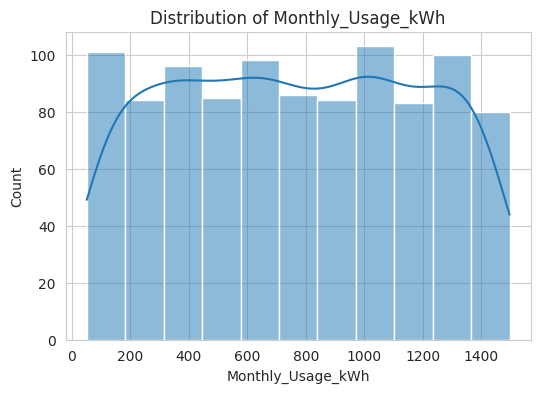

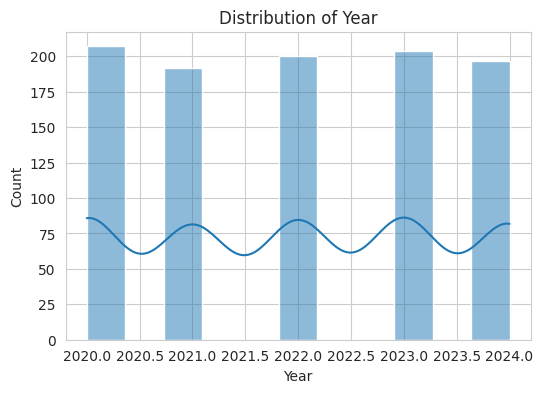

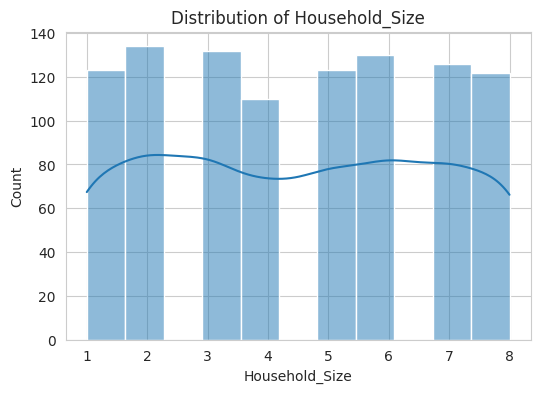

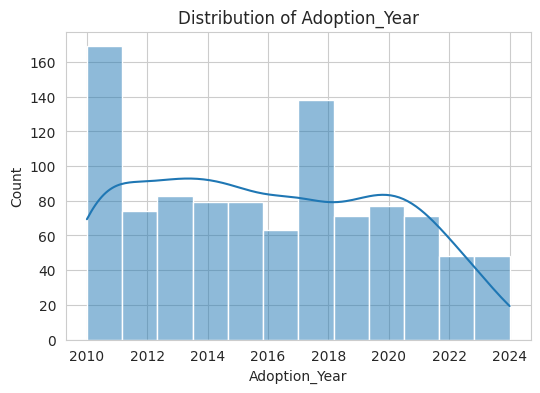

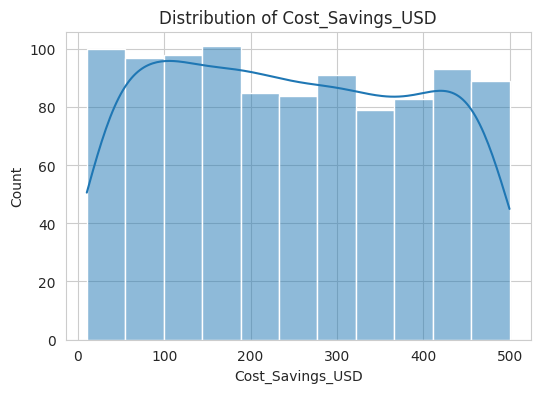

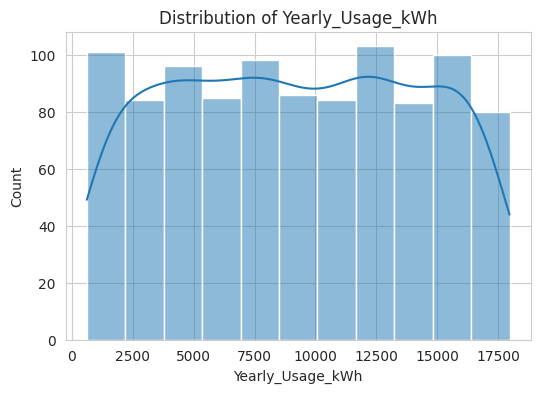

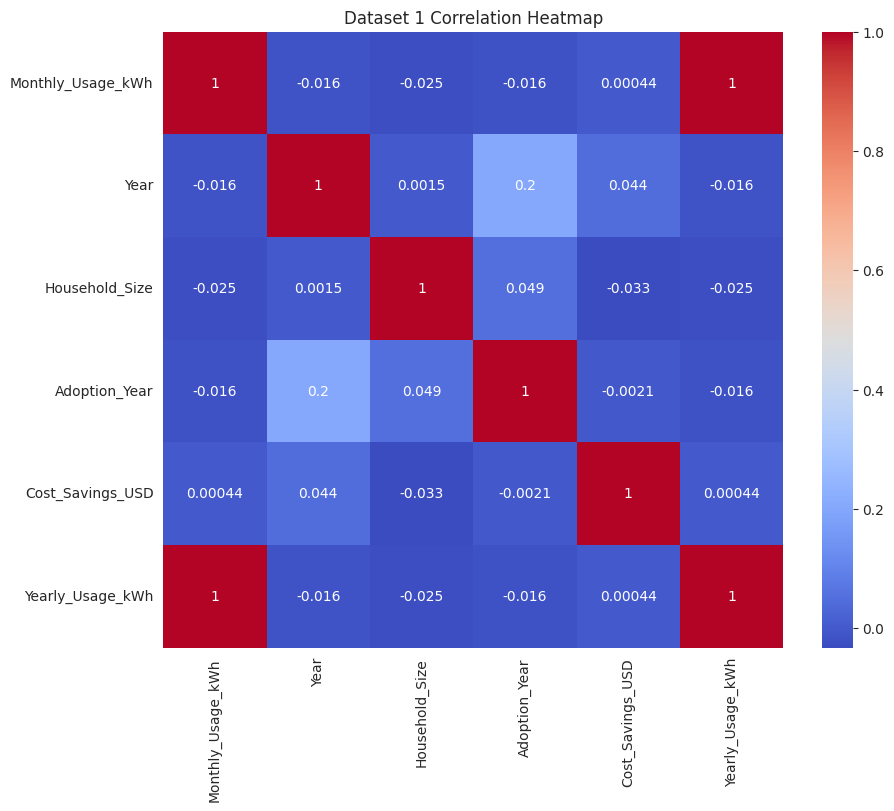

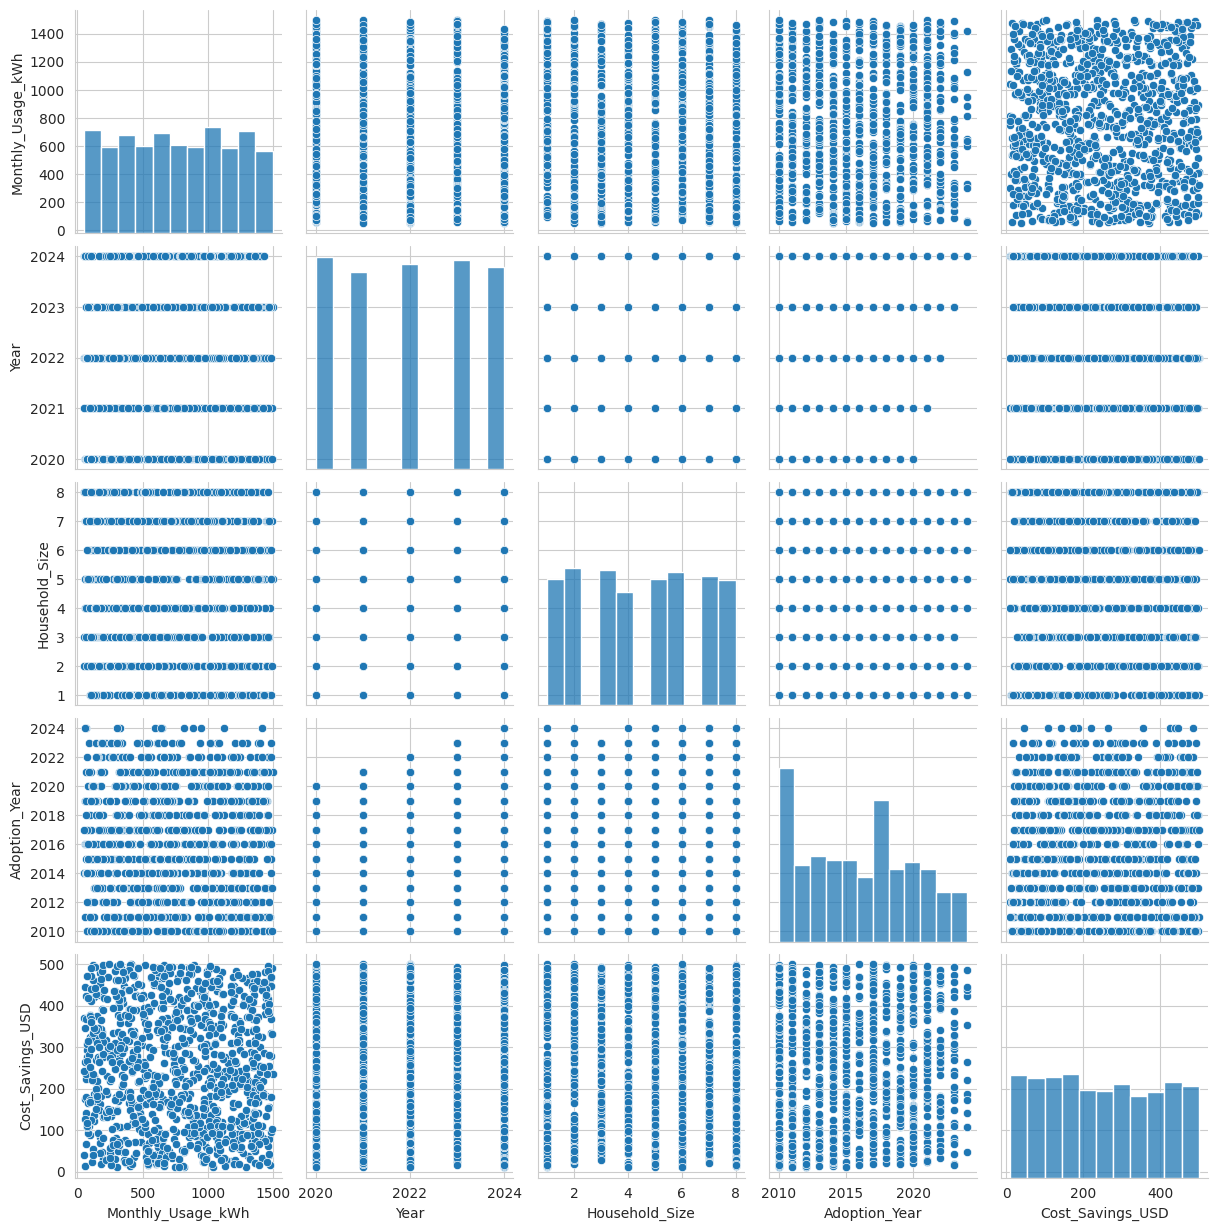

In [7]:
# ==================================================
# STEP 4 : EDA & VISUALIZATION
# ==================================================

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# -----------------------------
# DATASET 1
# -----------------------------

# Numerical columns
num_cols_1 = renewable_clean.select_dtypes(
    include=['int64', 'float64']
).columns

# Distribution Plots
for col in num_cols_1:
    plt.figure(figsize=(6,4))
    sns.histplot(renewable_clean[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    renewable_clean[num_cols_1].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Dataset 1 Correlation Heatmap")
plt.show()


# Pairplot (optional if dataset small)
sns.pairplot(
    renewable_clean[num_cols_1[:5]]
)
plt.show()

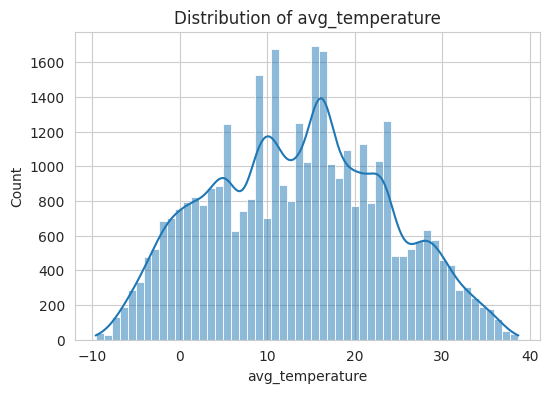

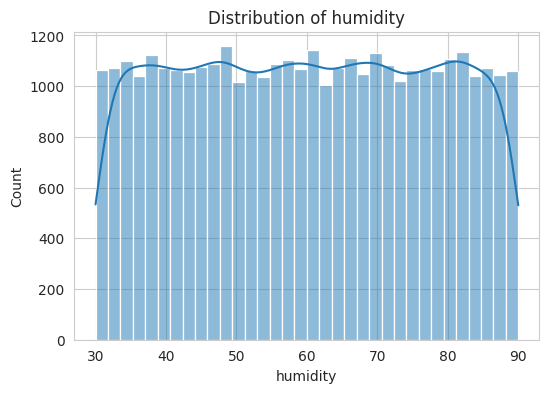

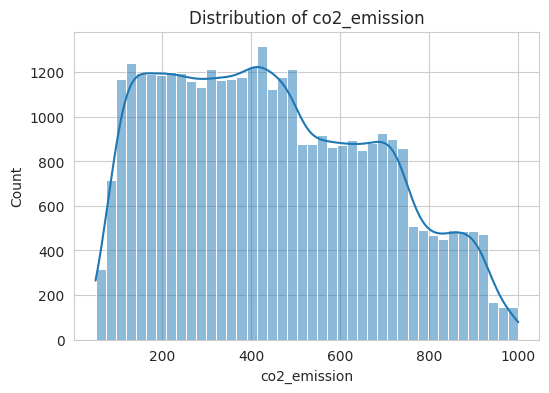

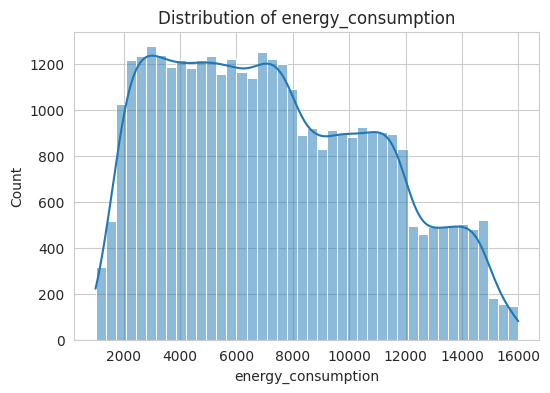

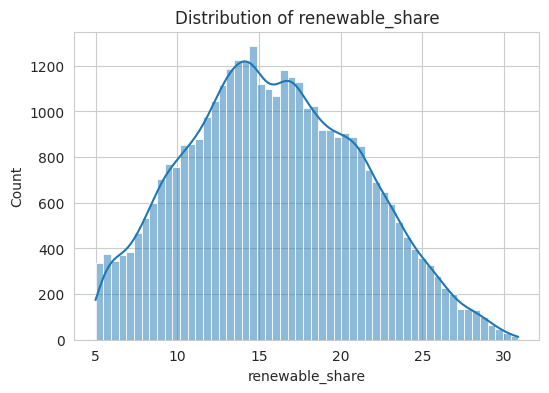

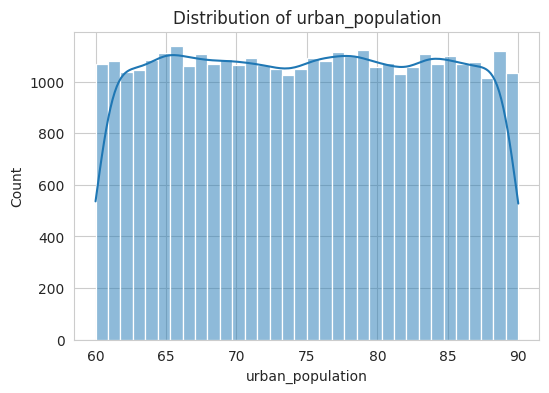

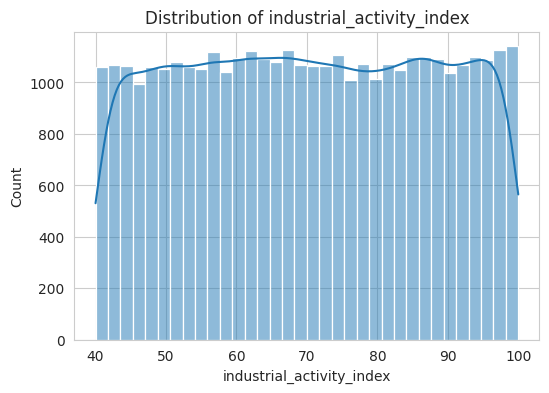

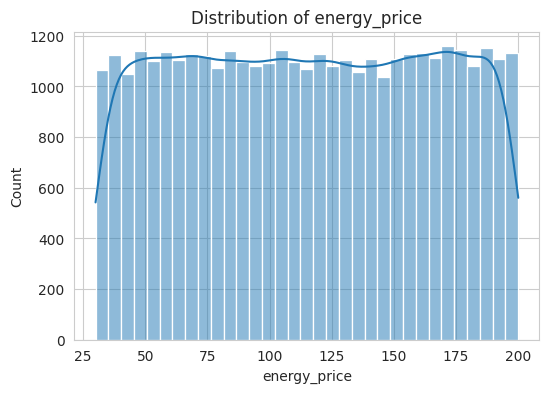

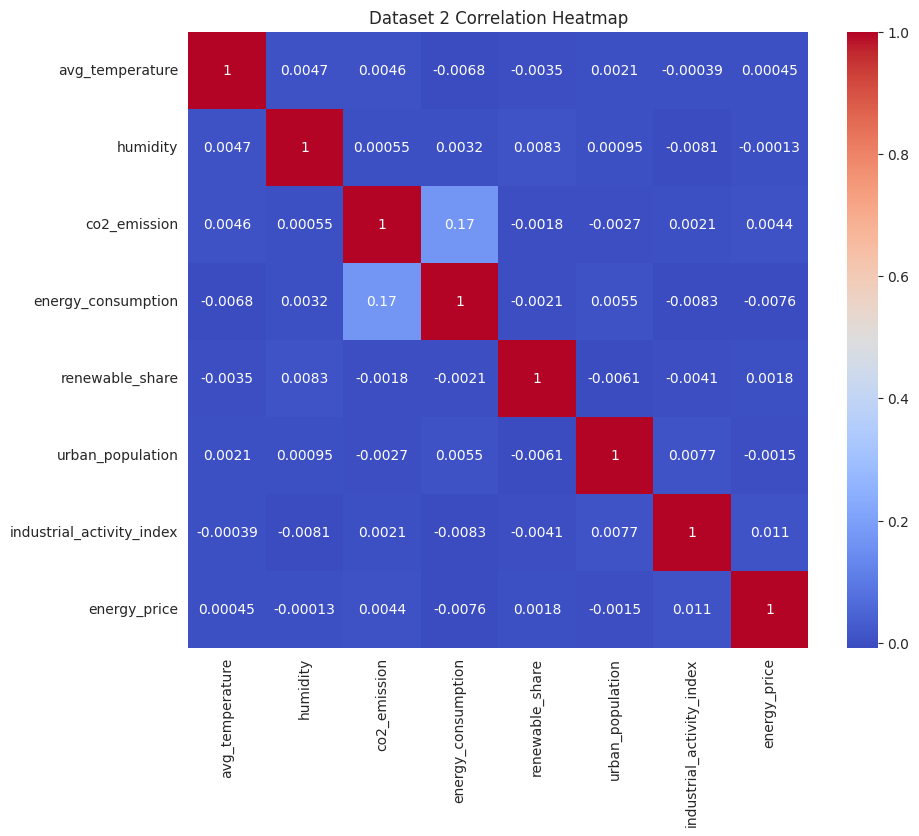

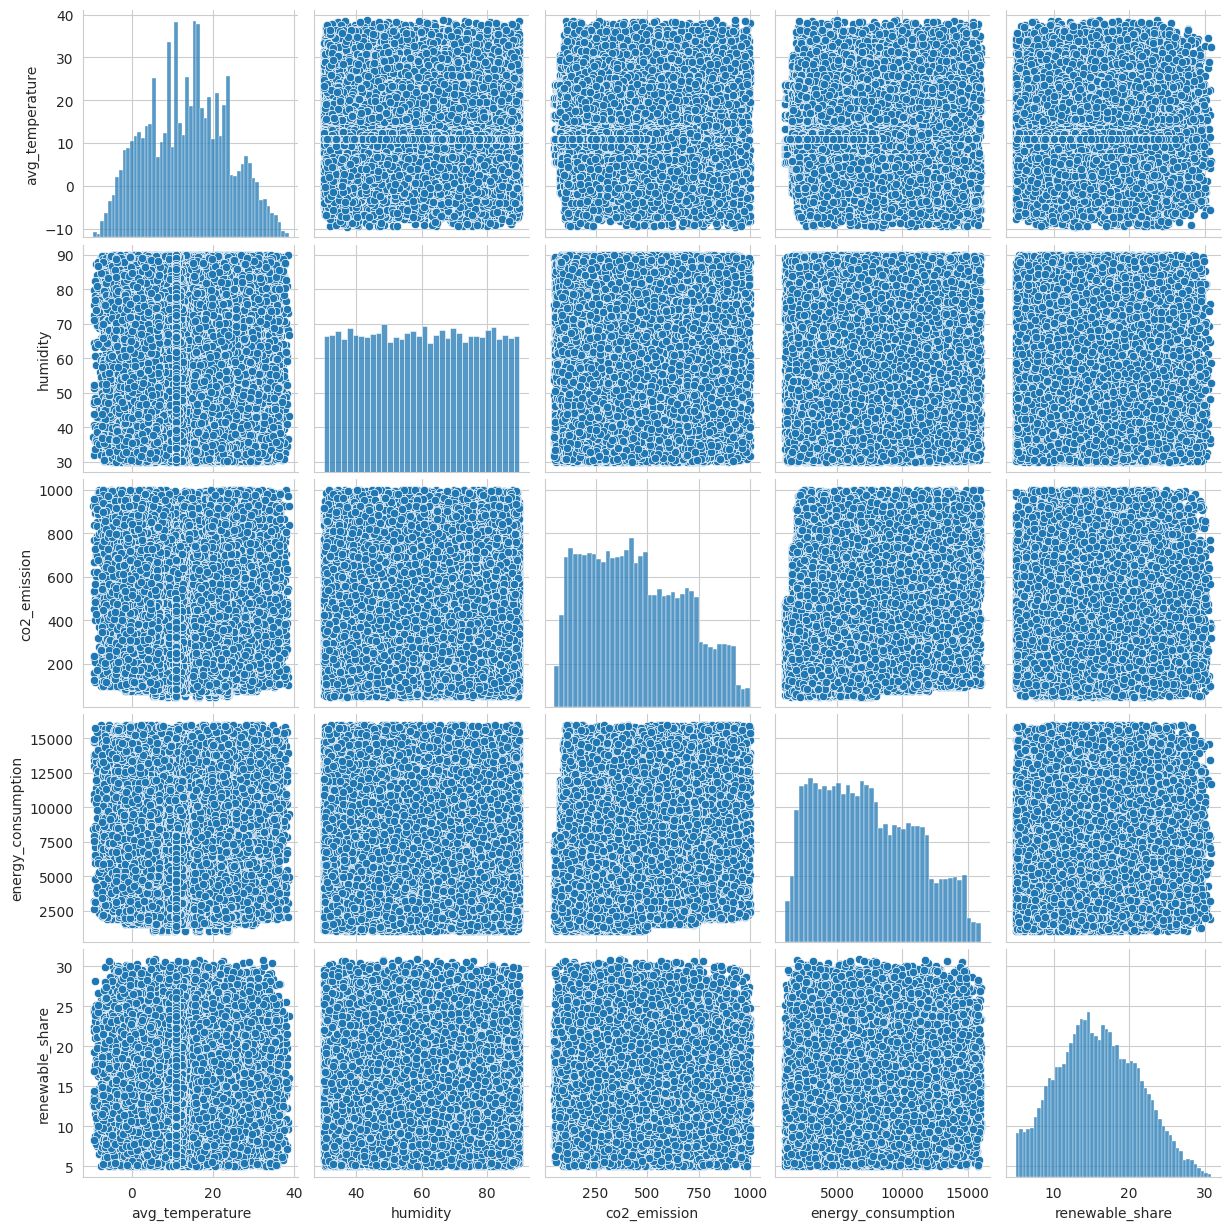

In [8]:
# -----------------------------
# DATASET 2
# -----------------------------

num_cols_2 = climate_clean.select_dtypes(
    include=['int64', 'float64']
).columns

for col in num_cols_2:
    plt.figure(figsize=(6,4))
    sns.histplot(climate_clean[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


plt.figure(figsize=(10,8))
sns.heatmap(
    climate_clean[num_cols_2].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Dataset 2 Correlation Heatmap")
plt.show()


sns.pairplot(
    climate_clean[num_cols_2[:5]]
)
plt.show()

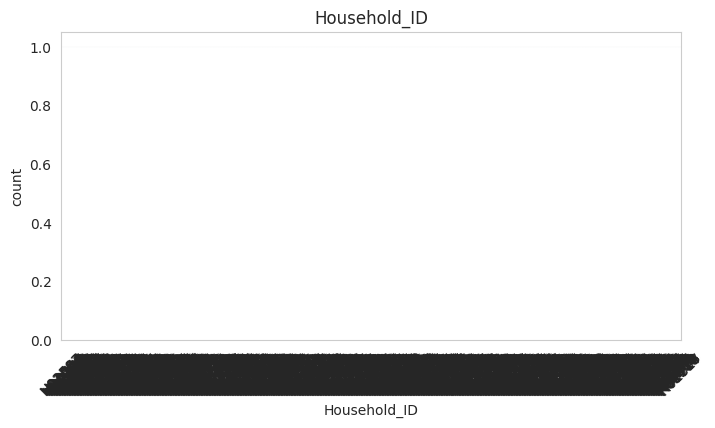

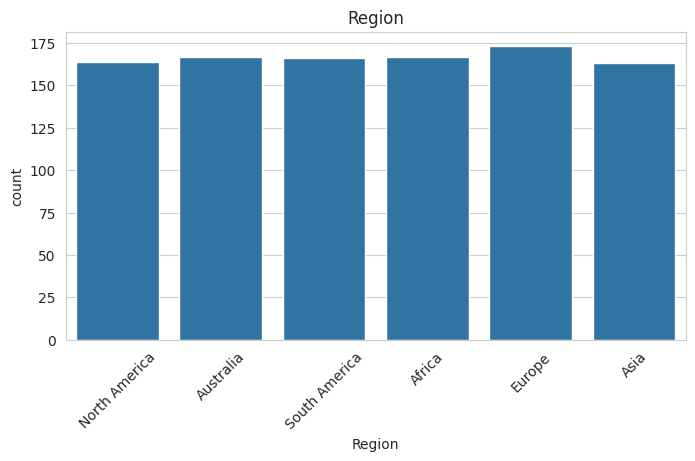

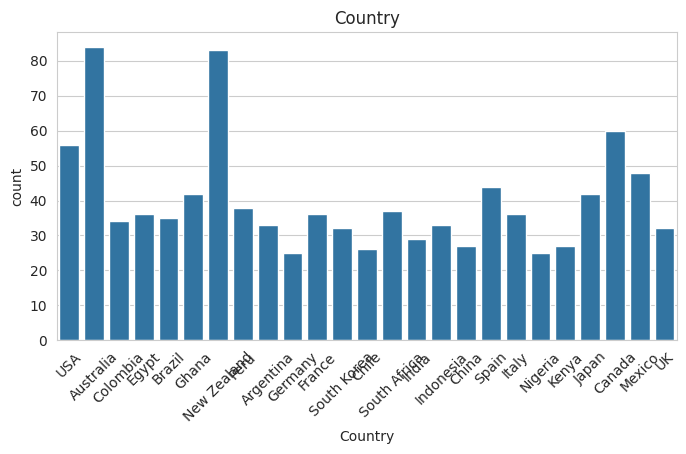

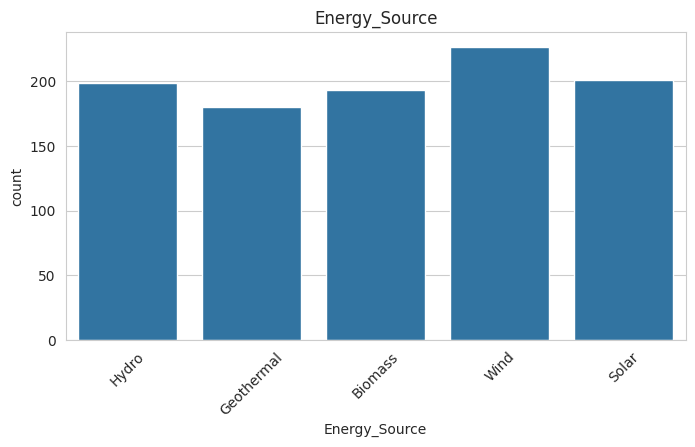

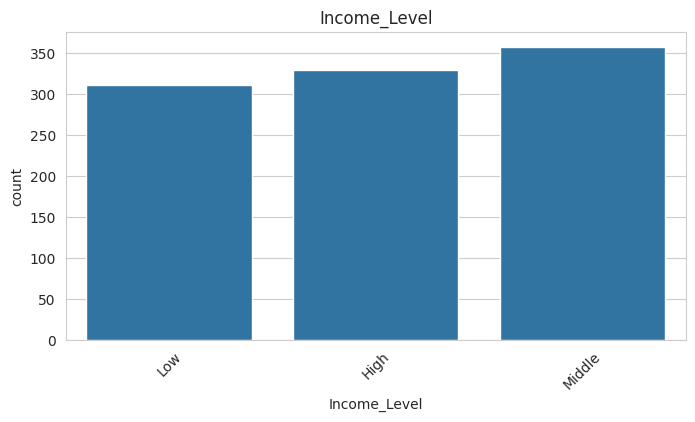

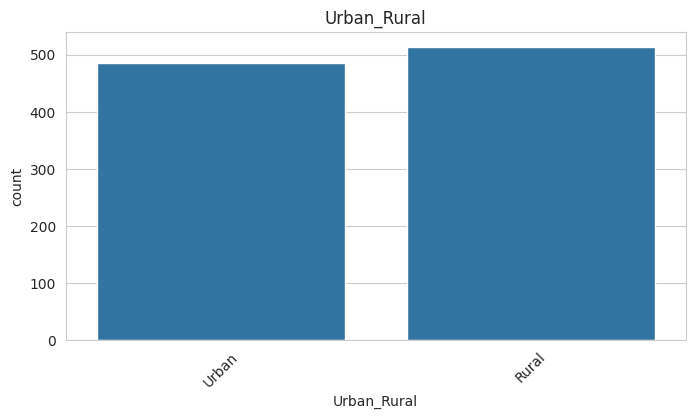

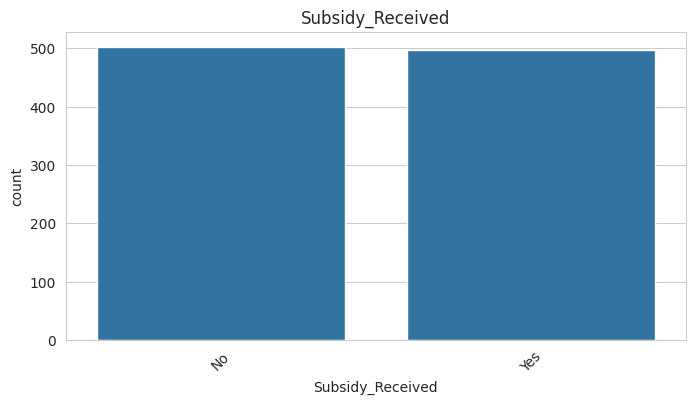

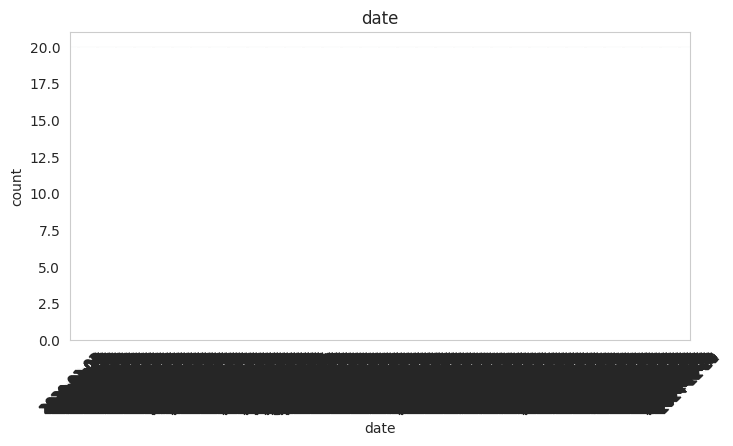

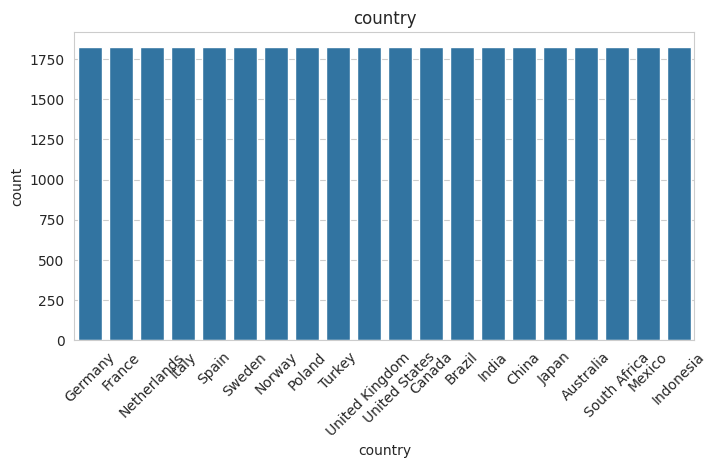

In [9]:
# ----------------------------------
# CATEGORICAL ANALYSIS DATASET 1
# ----------------------------------

cat_cols_1 = renewable_clean.select_dtypes(
    include=['object']
).columns

for col in cat_cols_1:
    plt.figure(figsize=(8,4))
    sns.countplot(
        x=renewable_clean[col]
    )
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()


# ----------------------------------
# CATEGORICAL ANALYSIS DATASET 2
# ----------------------------------

cat_cols_2 = climate_clean.select_dtypes(
    include=['object']
).columns

for col in cat_cols_2:
    plt.figure(figsize=(8,4))
    sns.countplot(
        x=climate_clean[col]
    )
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

EDA INSIGHTS

Why Histograms?
- To understand data distribution.
- To identify skewness and outliers.

Why Correlation Heatmap?
- To identify relationships between numerical features.
- Helps in selecting important features.
- Helps detect multicollinearity.

Why Pairplots?
- To visualize feature interactions.
- To detect clusters and trends.

Why Countplots?
- To understand category frequency.
- To detect class imbalance.

General Relationships to Observe:

Dataset 1:
- Higher renewable energy usage may increase cost savings.
- Larger households may consume more electricity.
- Subsidies may correlate with renewable adoption.

Dataset 2:
- Industrial activity may positively correlate with energy consumption.
- Renewable adoption may negatively correlate with CO2 emissions.
- Energy prices may influence consumption behavior.

Key Observations:
- Features with high positive correlation move together.
- Features with high negative correlation move inversely.
- Weak correlations may contribute little to prediction.

In [10]:
# ==================================================
# STEP 5 : ENCODING & SCALING
# ==================================================

from sklearn.preprocessing import StandardScaler

# ----------------------------------
# DATASET 1
# ----------------------------------

renewable_processed = renewable_clean.copy()

# Separate categorical columns
cat_cols_1 = renewable_processed.select_dtypes(
    include=['object']
).columns

# One Hot Encoding
renewable_processed = pd.get_dummies(
    renewable_processed,
    columns=cat_cols_1,
    drop_first=True
)

# Numerical columns
num_cols_1 = renewable_processed.select_dtypes(
    include=['int64', 'float64']
).columns

# Scale numerical features
scaler1 = StandardScaler()

renewable_processed[num_cols_1] = scaler1.fit_transform(
    renewable_processed[num_cols_1]
)

print("Dataset 1 Shape After Encoding:")
print(renewable_processed.shape)

print(renewable_processed.head())

Dataset 1 Shape After Encoding:
(1000, 1042)
   Monthly_Usage_kWh      Year  Household_Size  Adoption_Year  \
0           0.658414  1.415652        0.226438      -1.005126   
1          -0.375062  1.415652       -0.209020       1.764510   
2           1.023806  1.415652        1.532813       0.253799   
3          -0.328189  1.415652        1.097354       1.764510   
4          -1.175058  0.005640        1.097354      -1.508696   

   Cost_Savings_USD  Yearly_Usage_kWh  Household_ID_H00013  \
0         -1.663197          0.658414                False   
1         -1.432308         -0.375062                False   
2         -1.084262          1.023806                False   
3          1.569040         -0.328189                False   
4         -1.275097         -1.175058                False   

   Household_ID_H00018  Household_ID_H00020  Household_ID_H00024  \
0                False                False                False   
1                False                False            

In [11]:
# ----------------------------------
# DATASET 2
# ----------------------------------

climate_processed = climate_clean.copy()

cat_cols_2 = climate_processed.select_dtypes(
    include=['object']
).columns

climate_processed = pd.get_dummies(
    climate_processed,
    columns=cat_cols_2,
    drop_first=True
)

num_cols_2 = climate_processed.select_dtypes(
    include=['int64', 'float64']
).columns

scaler2 = StandardScaler()

climate_processed[num_cols_2] = scaler2.fit_transform(
    climate_processed[num_cols_2]
)

print("Dataset 2 Shape After Encoding:")
print(climate_processed.shape)

print(climate_processed.head())

Dataset 2 Shape After Encoding:
(36540, 1853)
   avg_temperature  humidity  co2_emission  energy_consumption  \
0         1.459658 -1.669751     -0.995019            1.097179   
1         1.468589 -1.273284      0.683697           -0.847149   
2         1.504313 -0.133011     -0.755684           -0.755874   
3         1.297905 -0.498846     -1.188356           -1.092828   
4         1.312790  0.312580     -0.221586           -0.073685   

   renewable_share  urban_population  industrial_activity_index  energy_price  \
0        -0.285690          0.162845                  -1.093369     -0.637481   
1        -1.933383          1.304509                   0.467096     -0.099229   
2        -0.326929          0.108480                  -1.223744      1.185500   
3        -0.394412         -1.368626                   1.571824     -0.531742   
4        -1.689697          0.120047                   0.675927     -1.518572   

   date_2020-01-02  date_2020-01-03  date_2020-01-04  date_2020-01-05 

In [12]:
# ==================================================
# STEP 6 : MACHINE LEARNING
# ==================================================

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import numpy as np

In [13]:
# ==================================================
# LINEAR REGRESSION
# ==================================================

target_reg = "Cost_Savings_USD"

X_reg = renewable_processed.drop(columns=[target_reg])

y_reg = renewable_processed[target_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()

linear_model.fit(
    X_train_reg,
    y_train_reg
)

y_pred_reg = linear_model.predict(
    X_test_reg
)

# Evaluation

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("LINEAR REGRESSION RESULTS")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

LINEAR REGRESSION RESULTS
MAE : 0.8646352570120173
MSE : 1.0322102018421304
RMSE : 1.0159774612864847
R2 Score : -0.06669363767058467


# Final Report

## Objective

Analyze two sustainability-related datasets, perform preprocessing, visualization, feature engineering, and build Regression and Classification models.

## Data Preprocessing

* Loaded and explored datasets.
* Removed duplicate records.
* Handled missing values using median (numerical) and mode (categorical).
* Applied feature engineering where required.
* Encoded categorical variables using `pd.get_dummies()`.
* Scaled numerical features using `StandardScaler`.

## Exploratory Data Analysis

* Used Seaborn histograms, countplots, pairplots, and heatmaps.
* Analyzed distributions and relationships between features.
* Identified important correlations for model building.

## Machine Learning Models

### Linear Regression

Target: Cost Savings

Evaluation Metrics:

* MAE
* MSE
* RMSE
* R² Score

Purpose:

* Predict continuous values.
* Measure impact of energy-related features on savings.

### Logistic Regression

Target: Subsidy Received

Evaluation Metrics:

* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix

Purpose:

* Classify whether a household receives a subsidy.

## Key Insights

* Higher renewable energy usage is associated with greater cost savings.
* Household size influences energy consumption.
* Renewable adoption may help reduce environmental impact.
* Industrial activity tends to increase energy consumption.

## Conclusion

The datasets were successfully cleaned, visualized, transformed, and modeled. Linear Regression and Logistic Regression provided predictive insights into sustainability-related factors, demonstrating the use of machine learning in green energy analysis.
